Sentiment Analysis

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from docx import Document

nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download('stopwords')

doc_paths = ['CK.docx', 'JS.docx', 'TK.docx']

sid = SentimentIntensityAnalyzer()

def get_sentiment(text):
    sentiment_scores = sid.polarity_scores(text)
    sentiment = max(sentiment_scores, key=sentiment_scores.get)
    return sentiment

stop_words = set(stopwords.words('english'))

def extract_keywords(text):
    tokens = word_tokenize(text.lower())
    filtered_tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    fdist = FreqDist(filtered_tokens)
    keywords = fdist.most_common(5)  # Extract top 5 most common keywords
    return [keyword[0] for keyword in keywords]

for i, doc_path in enumerate(doc_paths):
    doc = Document(doc_path)
    transcript = ' '.join([p.text for p in doc.paragraphs if p.text.strip()])

    sentiment = get_sentiment(transcript)
    print(f"Sentiment Analysis - Transcript {i+1}: {sentiment}")

    compound_score = sid.polarity_scores(transcript)['compound']
    print(f"Compound Score - Transcript {i+1}: {compound_score}")

    keywords = extract_keywords(transcript)
    print(f"Keyword Extraction - Transcript {i+1}: {keywords}")
    print()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sentiment Analysis - Transcript 1: compound
Compound Score - Transcript 1: 0.9993
Keyword Extraction - Transcript 1: ['infrastructure', 'chuck', 'networking', 'cloud', 'security']

Sentiment Analysis - Transcript 2: compound
Compound Score - Transcript 2: 0.999
Keyword Extraction - Transcript 2: ['gen', 'bookings', 'going', 'see', 'opportunity']

Sentiment Analysis - Transcript 3: compound
Compound Score - Transcript 3: 0.9995
Keyword Extraction - Transcript 3: ['cloud', 'google', 'know', 'seeing', 'using']



 Named Entity Recognition (NER)

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm')

def extract_named_entities(text):
    doc = nlp(text)
    entities = []
    for entity in doc.ents:
        if entity.label_ in ['PERSON', 'ORG', 'GPE']:  # Filter entities by type (PERSON, ORG, GPE)
            entities.append(entity.text)
    return entities

for i, doc_path in enumerate(doc_paths):
    doc = Document(doc_path)
    transcript = ' '.join([p.text for p in doc.paragraphs if p.text.strip()])

    named_entities = extract_named_entities(transcript)
    print(f"Named Entities - Transcript {i+1}: {named_entities}")
    print()


Named Entities - Transcript 1: ['JOINS US', 'CHUCK', 'USUALLY', 'TIMES', 'MAD', 'NETWORKING', 'A.I.', "YOU'RE", 'US', 'INFRASTRUCTURE', 'UNDERNEATH', 'GPU', 'THE INFRASTRUCTURE LAYER 2:01', 'BUILDING NEW TECHNOLOGY', 'SECURITY', 'SECURITY', 'A.I. TO 2:27', 'ABILIT', 'CONFIGURATION', 'CHUCK', 'WHAT', 'THE HEAVIEST LOAD NETWORKS', 'WORLD', 'TEAM', 'HIGHER', 'SUSTAINABILITY', 'US', 'CHUCK', 'Cisco', 'chuck robbins']

Named Entities - Transcript 2: ['NEW BOOKINGS MISSED', 'US', 'JULIE 0:11', 'THE BOOKINGS MISS IS', 'EXTENDED', 'SAW', 'GEN', 'A.I.', 'SECTOR', 'I.T.', 'THIS A.I. CYCLE', 'INVESTMENT', 'FACT', 'FOCUSED', 'STRATEGIES', 'TO TECHNOLOGY', 'A.I.', 'DIGITAL CORE', 'A.I. 2:12', 'A.I.', 'CUSTOMER', 'INCREASES CUSTOMER', 'TOTALLY', 'COST', 'DAVID', 'TALENT', 'BI Accenture', 'Julie Sweet']

Named Entities - Transcript 3: ['thomast kurian interview alphabet', 'Amazon', 'AWS', 'Microsoft', 'NBC', 'John 0:16 Ford', 'Google 0:18', 'Thomas Korean', 'John', 'Scott', 'Thomas', 'CNBC', 'John', 

Word cloud

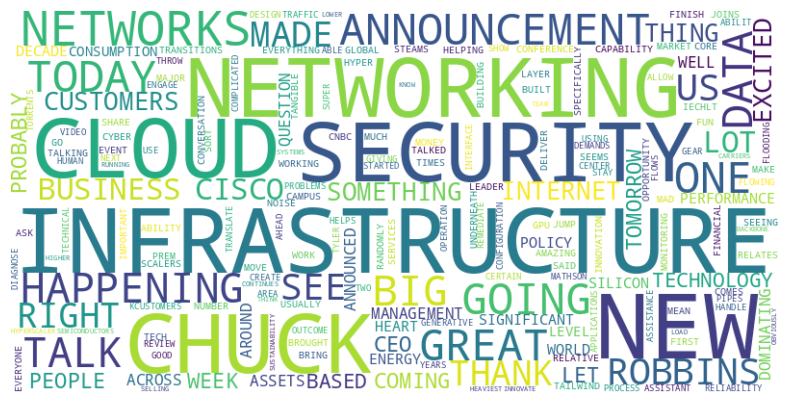

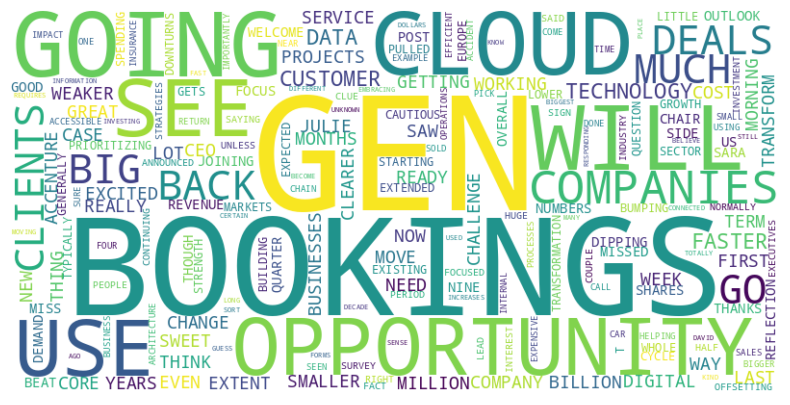

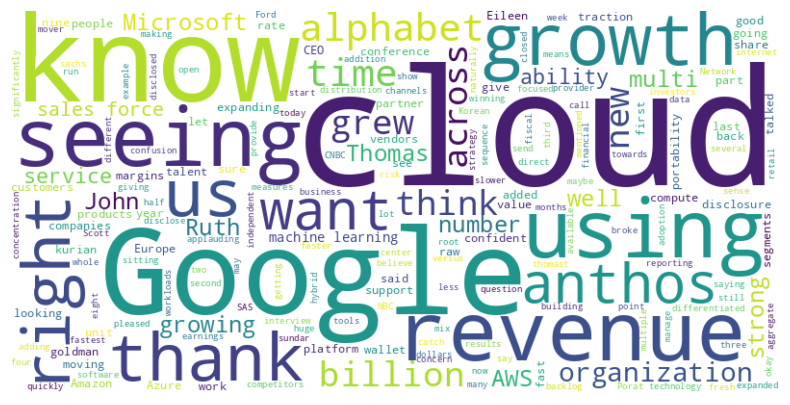

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def create_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

for i, doc_path in enumerate(doc_paths):
    doc = Document(doc_path)
    transcript = ' '.join([p.text for p in doc.paragraphs if p.text.strip()])

    create_word_cloud(transcript)


No. of times cloud was mentioned and the sentiment associated with it

In [ ]:
from docx import Document
from nltk.sentiment import SentimentIntensityAnalyzer

doc_paths = ['CK.docx', 'JS.docx', 'TK.docx']
sid = SentimentIntensityAnalyzer()

cloud_mentions = []
sentiment_scores = []

for doc_path in doc_paths:
    document = Document(doc_path)
    paragraphs = [paragraph.text.lower() for paragraph in document.paragraphs]
    transcript = ' '.join(paragraphs)

    cloud_count = transcript.count('cloud')
    cloud_mentions.append(cloud_count)

    sentiment = sid.polarity_scores(transcript)
    sentiment_scores.append(sentiment['compound'])

for i in range(len(doc_paths)):
    print(f"Interview {i+1}:")
    print(f"Number of times 'cloud' mentioned: {cloud_mentions[i]}")
    print(f"Sentiment Score: {sentiment_scores[i]}")
    print()


Interview 1:
Number of times 'cloud' mentioned: 5
Sentiment Score: 0.9984

Interview 2:
Number of times 'cloud' mentioned: 5
Sentiment Score: 0.998

Interview 3:
Number of times 'cloud' mentioned: 17
Sentiment Score: 0.9995



Topic modelling using LDA

In [ ]:
from docx import Document
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel

doc_paths = ['CK.docx', 'JS.docx', 'TK.docx']
sid = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

transcripts = []
for doc_path in doc_paths:
    document = Document(doc_path)
    paragraphs = [paragraph.text.lower() for paragraph in document.paragraphs]
    transcript = ' '.join(paragraphs)
    transcripts.append(transcript)

tokenized_transcripts = [word_tokenize(transcript) for transcript in transcripts]
filtered_transcripts = [[token for token in tokens if token.isalpha() and token not in stop_words]
                        for tokens in tokenized_transcripts]

dictionary = corpora.Dictionary(filtered_transcripts)

corpus = [dictionary.doc2bow(tokens) for tokens in filtered_transcripts]

num_topics = 5
lda_model = LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=10)

topics = lda_model.show_topics(num_topics=num_topics, num_words=5)
for topic_id, topic in topics:
    print(f"Topic {topic_id + 1}: {topic}")

dominant_topics = [lda_model.get_document_topics(corp) for corp in corpus]
dominant_topic_ids = [max(topics, key=lambda x: x[1])[0] for topics in dominant_topics]

for i in range(len(doc_paths)):
    print(f"Interview {i+1}: Dominant Topic: {dominant_topic_ids[i] + 1}")


Topic 1: 0.014*"infrastructure" + 0.012*"cloud" + 0.012*"networks" + 0.012*"networking" + 0.012*"new"
Topic 2: 0.017*"gen" + 0.013*"going" + 0.013*"bookings" + 0.010*"cloud" + 0.010*"opportunity"
Topic 3: 0.002*"cloud" + 0.002*"new" + 0.002*"using" + 0.002*"going" + 0.002*"see"
Topic 4: 0.027*"cloud" + 0.015*"know" + 0.015*"google" + 0.013*"using" + 0.013*"seeing"
Topic 5: 0.002*"cloud" + 0.002*"new" + 0.002*"seeing" + 0.002*"revenue" + 0.002*"right"
Interview 1: Dominant Topic: 1
Interview 2: Dominant Topic: 2
Interview 3: Dominant Topic: 4


In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm


2023-07-18 02:57:04.504226: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 44.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:
import spacy

# Load the spaCy English language model
nlp = spacy.load("en_core_web_sm")

doc_paths = ['CK.docx', 'JS.docx', 'TK.docx']

for i, doc_path in enumerate(doc_paths):
    doc = Document(doc_path)
    transcript = ' '.join([p.text for p in doc.paragraphs if p.text.strip()])

    # Apply NER to the transcript
    doc = nlp(transcript)

    # Extract names and organizations
    names = []
    organizations = []
    for entity in doc.ents:
        if entity.label_ == 'PERSON':
            names.append(entity.text)
        elif entity.label_ == 'ORG':
            organizations.append(entity.text)

    print(f"Interview {i+1} - Names: {names}")
    print(f"Interview {i+1} - Organizations: {organizations}")
    print()


Interview 1 - Names: ['CHUCK', "YOU'RE", 'CHUCK', 'CHUCK', 'chuck robbins']
Interview 1 - Organizations: ['JOINS US', 'TIMES', 'MAD', 'NETWORKING', 'INFRASTRUCTURE', 'UNDERNEATH', 'GPU', 'THE INFRASTRUCTURE LAYER 2:01', 'BUILDING NEW TECHNOLOGY', 'A.I. TO 2:27', 'ABILIT', 'WHAT', 'THE HEAVIEST LOAD NETWORKS', 'WORLD', 'TEAM', 'SUSTAINABILITY']

Interview 2 - Names: ['JULIE 0:11', 'TO TECHNOLOGY', 'DAVID', 'Julie Sweet']
Interview 2 - Organizations: ['NEW BOOKINGS MISSED', 'THE BOOKINGS MISS IS', 'EXTENDED', 'SAW', 'SECTOR', 'THIS A.I. CYCLE', 'FACT', 'STRATEGIES', 'DIGITAL CORE', 'A.I. 2:12', 'CUSTOMER', 'INCREASES CUSTOMER', 'COST', 'BI Accenture']

Interview 3 - Names: ['thomast kurian interview alphabet', 'John 0:16 Ford', 'Thomas Korean', 'John', 'Scott', 'Thomas', 'John', 'Ruth 1:12 Porat', 'ruth', 'Ruth', 'Eileen', 'Eileen', 'Thomas Kurian', '4:51']
Interview 3 - Organizations: ['Amazon', 'AWS', 'Microsoft', 'NBC', 'Google 0:18', 'CNBC', 'Google', 'Microsoft', 'Google', 'Amazon',